# 09 · Model Evaluation & Improvement

A single accuracy number can lie. This notebook is about *trusting* your evaluation:

- **Cross-validation** — a stable score instead of one lucky split.
- **The right metric** — accuracy, precision, recall, F1, ROC-AUC, and when each matters.
- **The confusion matrix** — where errors actually happen.
- **Grid search** — tuning hyperparameters without fooling yourself.
- **Imbalanced data** — why accuracy is dangerous when classes are lopsided.

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
d = load_breast_cancer()
Xtr, Xte, ytr, yte = train_test_split(d.data, d.target, test_size=0.25,
                                      random_state=0, stratify=d.target)

## 1. Cross-validation: one split isn't enough

A single train/test split can be lucky or unlucky. **k-fold cross-validation** splits the data
`k` ways, trains `k` times (each fold takes a turn as the test set), and averages. The spread
across folds tells you how *stable* the model is.

In [2]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

scores = cross_val_score(RandomForestClassifier(random_state=0), d.data, d.target, cv=5)
print("fold scores:", scores.round(3))
print(f"mean {scores.mean():.3f}  ±  {scores.std():.3f}")

fold scores: [0.93  0.947 0.991 0.974 0.973]
mean 0.963  ±  0.022


## 2. Beyond accuracy: precision, recall, F1

Accuracy = fraction correct. But for a cancer screen, missing a malignant case (false negative)
is far worse than a false alarm. So we separate:

- **Precision** — of everything flagged positive, how much really was? (controls false alarms)
- **Recall** — of all true positives, how many did we catch? (controls misses)
- **F1** — their harmonic mean, a single balanced number.

In [3]:
from sklearn.metrics import classification_report
rf = RandomForestClassifier(random_state=0).fit(Xtr, ytr)
pred = rf.predict(Xte)
print(classification_report(yte, pred, target_names=d.target_names))

              precision    recall  f1-score   support

   malignant       0.92      0.92      0.92        53
      benign       0.96      0.96      0.96        90

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



## 3. The confusion matrix shows *where* it fails

Four cells: correct positives/negatives on the diagonal, the two error types off it. Reading
it tells you whether your model's mistakes are false alarms or dangerous misses.

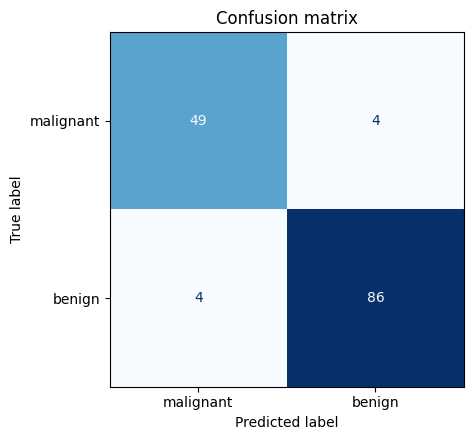

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(yte, pred, display_labels=d.target_names,
                                        cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion matrix"); plt.tight_layout(); plt.show()

## 4. ROC curve & AUC: performance across all thresholds

Instead of committing to a 0.5 threshold, the **ROC curve** sweeps every threshold and plots
true-positive rate vs false-positive rate. The **area under it (AUC)** summarizes the model in
one threshold-independent number: 1.0 is perfect, 0.5 is random guessing.

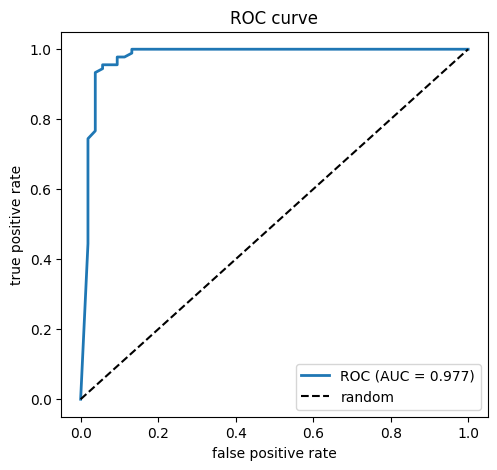

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score
proba = rf.predict_proba(Xte)[:, 1]
fpr, tpr, _ = roc_curve(yte, proba)
auc = roc_auc_score(yte, proba)

plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="random")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("ROC curve"); plt.legend(); plt.show()

## 5. Grid search: tune without cheating

Hyperparameters (like tree depth, or SVM's `C`/`gamma`) aren't learned — you choose them.
`GridSearchCV` tries combinations using cross-validation *on the training set*, so the test
set stays untouched until the very end. That discipline is what keeps your final score honest.

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(StandardScaler(), SVC())
grid = {"svc__C": [0.1, 1, 10, 100], "svc__gamma": [0.001, 0.01, 0.1]}
search = GridSearchCV(pipe, grid, cv=5, n_jobs=-1)
search.fit(Xtr, ytr)

print("best params:", search.best_params_)
print(f"best CV score:  {search.best_score_:.3f}")
print(f"held-out test:  {search.score(Xte, yte):.3f}")

best params: {'svc__C': 100, 'svc__gamma': 0.001}
best CV score:  0.988
held-out test:  0.958


## 6. Imbalanced data: when accuracy lies

If 99% of samples are one class, a model that always predicts that class is "99% accurate" and
useless. We simulate imbalance and show accuracy staying high while recall on the rare class
collapses — which is why you pick the metric that matches the cost of each error.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score

rng = np.random.RandomState(0)
# make class 0 rare: keep only 5% of the malignant samples
mask = (d.target == 1) | (rng.rand(len(d.target)) < 0.05)
Xi, yi = d.data[mask], d.target[mask]
print(f"class balance: {np.bincount(yi)}  (very lopsided)")

Xitr, Xite, yitr, yite = train_test_split(Xi, yi, test_size=0.3, random_state=0, stratify=yi)
m = LogisticRegression(max_iter=5000).fit(Xitr, yitr)
p = m.predict(Xite)
print(f"accuracy on rare-positive:            {accuracy_score(yite, p):.1%}  <- looks great")
print(f"recall on the RARE class (class 0):   {recall_score(yite, p, pos_label=0):.1%}  <- the truth")

class balance: [ 12 357]  (very lopsided)
accuracy on rare-positive:            99.1%  <- looks great
recall on the RARE class (class 0):   75.0%  <- the truth


## Recap

- **Cross-validate** for a stable score plus its spread.
- **Accuracy isn't enough**: use **precision/recall/F1** matched to the cost of each error.
- The **confusion matrix** shows which errors happen; **ROC-AUC** summarizes across thresholds.
- **GridSearchCV** tunes on training folds only — the test set is sacred.
- On **imbalanced** data, accuracy misleads; watch recall on the rare class.

**Next:** `10 — Pipelines`, which bundle all of this into one leak-proof object.